In [8]:
import pandas as pd

In [9]:
df = pd.read_csv('Raw Dataset.csv')
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,00:00:00,06:00:00,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,08:08:00,08:10:00,199
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,09:19:00,09:21:00,312
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,12:38:00,12:40:00,577


# ****Level 1: Understanding the Data****

## ****Task 1.1: Check the dataset for total records and columns****

In [10]:
df.shape

(186074, 12)

In [11]:
pd.DataFrame([df.shape], columns=['Rows', 'Columns']).T

,0
Rows,186074
Columns,12


## ****Task 1.2: Create a train-wise table showing starting and ending stations****


In [12]:
df['Train_No'].unique()

array([  107,   108,   128, ..., 99907, 99908, 22439], shape=(11113,))

In [13]:
Station_Name_Start = df[df['Distance'] == 0][['Train_No', 'Station_Name']]
Station_Name_Start = Station_Name_Start.rename(columns={'Station_Name': 'Station_Name_Start'})

In [14]:
Last_Stop = df.groupby('Train_No')['Distance'].idxmax()
Station_Name_End = df.loc[Last_Stop, ['Train_No', 'Station_Name']]
Station_Name_End = Station_Name_End.rename(columns={'Station_Name': 'Station_Name_End'})

In [15]:
Train_Wise_Table = pd.merge(Station_Name_Start, Station_Name_End, on=['Train_No'])
Train_Wise_Table

,Train_No,Station_Name_Start,Station_Name_End
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.
...,...,...,...
11119,99905,TALEGAON,SHIVAJINAGAR
11120,99906,PUNE JN.,TALEGAON
11121,99907,TALEGAON,PUNE JN.
11122,99908,PUNE JN.,TALEGAON


## ****Task 1.3: Calculate basic statistics for distance and number of stops****

In [16]:
df['Distance'].describe().to_frame()

,Distance
count,186074.000000
mean,281.353838
std,483.743964
min,0.000000
25%,23.000000
50%,73.000000
75%,291.000000
max,4260.000000


In [17]:
Number_Of_Stops_Each_Train = df.groupby('Train_No').size()
Number_Of_Stops_Each_Train

Train_No
107       4
108       4
128      22
290      14
401      12
         ..
99904    12
99905    11
99906    12
99907    12
99908    12
Length: 11113, dtype: int64

In [18]:
Number_Of_Stops_Each_Train.describe().to_frame()

,0
count,11113.000000
mean,16.743814
std,12.993123
min,2.000000
25%,8.000000
50%,15.000000
75%,22.000000
max,118.000000


## ****Task 1.4: Identify missing, duplicate, or incorrect values****


In [19]:
df.isnull().sum()

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

#### ****So, no missing values****

In [20]:
df.duplicated().unique()

array([False])

#### ****So, no duplicate values****

In [21]:
df.describe()

,SN,Train_No,1A,2A,3A,SL,Route_Number,Distance
count,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.0,186074.000000
mean,13.914695,42157.747455,1506.769189,1225.415351,944.061513,662.735777,1.0,281.353838
std,12.779368,25090.080221,2418.719821,1934.975856,1451.231892,967.524012,0.0,483.743964
min,1.000000,107.000000,100.000000,100.000000,100.000000,100.000000,1.0,0.000000
25%,5.000000,17225.000000,215.000000,192.000000,169.000000,146.000000,1.0,23.000000
50%,11.000000,40050.000000,465.000000,392.000000,319.000000,246.000000,1.0,73.000000
75%,18.000000,57550.000000,1555.000000,1264.000000,973.000000,682.000000,1.0,291.000000
max,118.000000,99908.000000,21400.000000,17140.000000,12880.000000,8620.000000,1.0,4260.000000


#### ****After analyzing dataset, we can conclude that there is no incorrect values****

# ****Level 2: Data Cleaning and Feature Creation****

## ****Task 2.1: Handle missing values and remove duplicate records****

#### ****There is no missing values and duplicate records****

## ****Task 2.2: Convert arrival and departure times into a machine-learning-friendly format****

In [22]:
df['Arrival_time'] = pd.to_datetime(df['Arrival_time'], format='%H:%M:%S')

In [23]:
df['Arrival_time_Hour'] = df['Arrival_time'].dt.hour
df['Arrival_time_Minute'] = df['Arrival_time'].dt.minute
df['Arrival_time_Second'] = df['Arrival_time'].dt.second

In [24]:
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Arrival_time_Hour,Arrival_time_Minute,Arrival_time_Second
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,1900-01-01 00:00:00,10:25:00,0,0,0,0
1,2,107,THVM,260,228,196,164,THIVIM,1,1900-01-01 11:06:00,11:08:00,32,11,6,0
2,3,107,KRMI,345,296,247,198,KARMALI,1,1900-01-01 11:28:00,11:30:00,49,11,28,0
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,1900-01-01 12:10:00,00:00:00,78,12,10,0
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,1900-01-01 00:00:00,20:30:00,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,1900-01-01 00:00:00,06:00:00,0,0,0,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,1900-01-01 08:08:00,08:10:00,199,8,8,0
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,1900-01-01 09:19:00,09:21:00,312,9,19,0
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,1900-01-01 12:38:00,12:40:00,577,12,38,0


In [25]:
df['Departure_Time'] = pd.to_datetime(df['Departure_Time'], format='%H:%M:%S')

In [26]:
df['Departure_Time_Hour'] = df['Departure_Time'].dt.hour
df['Departure_Time_Minute'] = df['Departure_Time'].dt.minute
df['Departure_Time_Second'] = df['Departure_Time'].dt.second

In [27]:
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Arrival_time_Hour,Arrival_time_Minute,Arrival_time_Second,Departure_Time_Hour,Departure_Time_Minute,Departure_Time_Second
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,1900-01-01 00:00:00,1900-01-01 10:25:00,0,0,0,0,10,25,0
1,2,107,THVM,260,228,196,164,THIVIM,1,1900-01-01 11:06:00,1900-01-01 11:08:00,32,11,6,0,11,8,0
2,3,107,KRMI,345,296,247,198,KARMALI,1,1900-01-01 11:28:00,1900-01-01 11:30:00,49,11,28,0,11,30,0
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,1900-01-01 12:10:00,1900-01-01 00:00:00,78,12,10,0,0,0,0
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,1900-01-01 00:00:00,1900-01-01 20:30:00,0,0,0,0,20,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,1900-01-01 00:00:00,1900-01-01 06:00:00,0,0,0,0,6,0,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,1900-01-01 08:08:00,1900-01-01 08:10:00,199,8,8,0,8,10,0
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,1900-01-01 09:19:00,1900-01-01 09:21:00,312,9,19,0,9,21,0
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,1900-01-01 12:38:00,1900-01-01 12:40:00,577,12,38,0,12,40,0


## ****Task 2.3: Calculate total journey duration for each train as the target variable****

In [28]:
df = df.sort_values(by=['Train_No', 'SN'])

In [29]:
Start_Time = df.groupby('Train_No')['Departure_Time'].first()
End_Time = df.groupby('Train_No')['Arrival_time'].last()

In [30]:
Start_DateTime = pd.to_datetime(Start_Time)
End_DateTime = pd.to_datetime(End_Time)

In [31]:
Total_Duration_Minute_Each_Train = End_DateTime - Start_DateTime
Total_Duration_Minute_Each_Train = Total_Duration_Minute_Each_Train.mask(Total_Duration_Minute_Each_Train < pd.Timedelta(0), Total_Duration_Minute_Each_Train + pd.Timedelta(days=1))
Total_Duration_Minute_Each_Train = Total_Duration_Minute_Each_Train.dt.total_seconds() / 60

## ****Task 2.4: Create input features such as total distance and total number of stops****

In [32]:
Total_Distance_Each_Train = df.groupby('Train_No')['Distance'].max()

In [33]:
Total_Distance_Each_Train

Train_No
107        78
108        83
128       978
290      2694
401      1618
         ... 
99904      34
99905      31
99906      34
99907      34
99908      34
Name: Distance, Length: 11113, dtype: int64

In [34]:
Total_Distance_Each_Train.describe()

count    11113.000000
mean       348.870242
std        596.179751
min          1.000000
25%         38.000000
50%         82.000000
75%        324.000000
max       4260.000000
Name: Distance, dtype: float64

In [35]:
Number_Of_Stops_Each_Train

Train_No
107       4
108       4
128      22
290      14
401      12
         ..
99904    12
99905    11
99906    12
99907    12
99908    12
Length: 11113, dtype: int64

In [36]:
Number_Of_Stops_Each_Train.describe()

count    11113.000000
mean        16.743814
std         12.993123
min          2.000000
25%          8.000000
50%         15.000000
75%         22.000000
max        118.000000
dtype: float64

In [37]:
df = pd.concat([Total_Duration_Minute_Each_Train, Total_Distance_Each_Train, Number_Of_Stops_Each_Train], axis=1)
df.columns = ['Total_Duration_Minute', 'Total_Distance', 'Number_Of_Stops']
df = df.reset_index()

In [38]:
df

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,480.0,2694,14
4,401,750.0,1618,12
...,...,...,...,...
11108,99904,50.0,34,12
11109,99905,43.0,31,11
11110,99906,50.0,34,12
11111,99907,52.0,34,12


In [39]:
df.describe()

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
count,11113.000000,11113.000000,11113.000000,11113.000000
mean,49190.570413,276.013498,348.870242,16.743814
std,28515.986645,321.166943,596.179751,12.993123
min,107.000000,0.000000,1.000000,2.000000
25%,22607.000000,61.000000,38.000000,8.000000
50%,47174.000000,132.000000,82.000000,15.000000
75%,68012.000000,365.000000,324.000000,22.000000
max,99908.000000,1435.000000,4260.000000,118.000000


# ****Level 3: Feature Analysis with Visuals****

## ****Task 3.1: Visualize how distance affects journey duration****


In [40]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Total Distance')

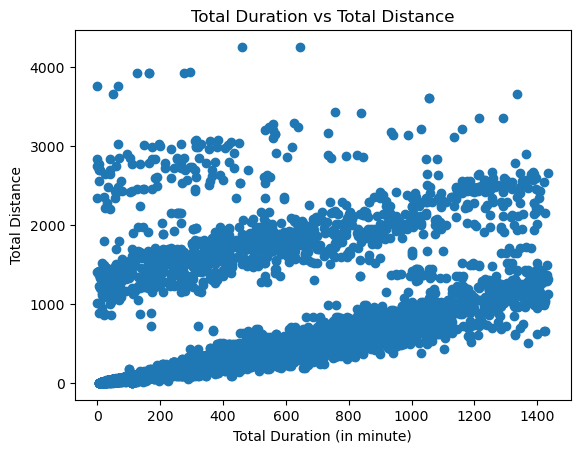

In [41]:
plt.scatter(df['Total_Duration_Minute'], df['Total_Distance'])
plt.title('Total Duration vs Total Distance')
plt.xlabel('Total Duration (in minute)')
plt.ylabel('Total Distance')

In [42]:
df = df[df['Total_Distance'] <= 3000]

In [43]:
df

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,480.0,2694,14
4,401,750.0,1618,12
...,...,...,...,...
11108,99904,50.0,34,12
11109,99905,43.0,31,11
11110,99906,50.0,34,12
11111,99907,52.0,34,12


## ****Task 3.2: Visualize the impact of number of stops on journey duration****

Text(0.5, 0, 'Total Duration (in minute)')

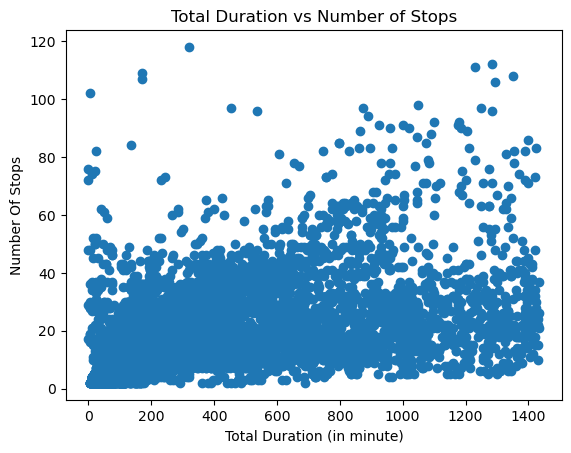

In [44]:
plt.scatter(df['Total_Duration_Minute'], df['Number_Of_Stops'])
plt.title('Total Duration vs Number of Stops')
plt.ylabel('Number Of Stops')
plt.xlabel('Total Duration (in minute)')

In [45]:
df = df[df['Number_Of_Stops'] <= 100]

In [46]:
df

,Train_No,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,107,105.0,78,4
1,108,115.0,83,4
2,128,1325.0,978,22
3,290,480.0,2694,14
4,401,750.0,1618,12
...,...,...,...,...
11108,99904,50.0,34,12
11109,99905,43.0,31,11
11110,99906,50.0,34,12
11111,99907,52.0,34,12


## ****Task 3.3: Create correlation visuals between input features and journey duration****


In [47]:
correlation = df.corr()[['Total_Duration_Minute']].sort_values(by='Total_Duration_Minute', ascending=False)
correlation = correlation.drop(index='Total_Duration_Minute')

In [48]:
import seaborn as sns

Text(0.5, 1.0, 'Correlation Between Features')

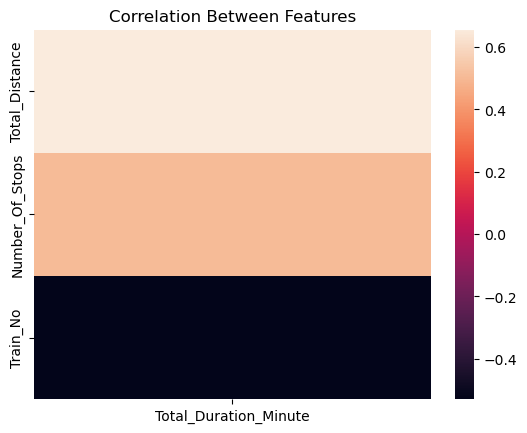

In [49]:
sns.heatmap(correlation)
plt.title("Correlation Between Features")

### ****Since Total Duration has no correlation with Train No, let's remove the column completely****

In [50]:
df = df.drop('Train_No', axis=1)

In [51]:
df

,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,105.0,78,4
1,115.0,83,4
2,1325.0,978,22
3,480.0,2694,14
4,750.0,1618,12
...,...,...,...
11108,50.0,34,12
11109,43.0,31,11
11110,50.0,34,12
11111,52.0,34,12


## ****Task 3.4: Build a pivot table summarizing number of stops for each train****

In [52]:
df['Number_Of_Stops'].unique()

array([ 4, 22, 14, 12,  5,  9,  3,  2, 18, 10, 11, 24, 26, 17, 13,  7, 16,
       29, 21,  6, 15, 20, 53, 27, 19, 85,  8, 36, 34, 28, 40, 37, 39, 30,
       33, 49, 47, 38, 46, 31, 52, 35, 62, 60, 23, 90, 91, 41, 43, 67, 65,
       25, 32, 45, 50, 56, 54, 48, 42, 44, 63, 64, 51, 57, 77, 78, 66, 89,
       82, 84, 96, 97, 74, 71, 61, 58, 73, 59, 55, 81, 72, 83, 76, 75, 98,
       92, 94, 68, 70, 86, 79, 88, 87])

In [53]:
Pivot_Table = pd.pivot_table(
    df,
    values=['Total_Duration_Minute', 'Total_Distance'], 
    index='Number_Of_Stops',                            
    aggfunc='max')

In [54]:
Pivot_Table

,Total_Distance,Total_Duration_Minute
Number_Of_Stops,,
2,1301,690.0
3,1429,630.0
4,1376,965.0
5,1449,1300.0
6,2351,1345.0
...,...,...
92,1678,1180.0
94,1759,890.0
96,2535,1285.0


In [55]:
Pivot_Table.describe()

,Total_Distance,Total_Duration_Minute
count,93.000000,93.000000
mean,2243.236559,1271.774194
std,589.197564,209.872691
min,618.000000,135.000000
25%,1945.000000,1205.000000
50%,2353.000000,1345.000000
75%,2729.000000,1405.000000
max,2993.000000,1435.000000


In [56]:
Pivot_Table = pd.pivot_table(
    df,
    values=['Total_Duration_Minute', 'Total_Distance'], 
    index='Number_Of_Stops',                            
    aggfunc='mean')

In [57]:
Pivot_Table

,Total_Distance,Total_Duration_Minute
Number_Of_Stops,,
2,33.341873,52.306645
3,47.201571,66.664921
4,77.919118,85.507353
5,147.828000,146.628000
6,163.204819,161.903614
...,...,...
92,1140.000000,1140.000000
94,1759.000000,890.000000
96,2256.500000,910.000000


In [58]:
Pivot_Table.describe()

,Total_Distance,Total_Duration_Minute
count,93.000000,93.000000
mean,868.270544,635.976096
std,489.328731,314.431642
min,33.341873,52.306645
25%,514.164384,375.836364
50%,871.000000,641.750000
75%,1133.076923,869.000000
max,2256.500000,1400.000000


In [59]:
df.isnull().sum()

Total_Duration_Minute    0
Total_Distance           0
Number_Of_Stops          0
dtype: int64

In [60]:
df = df.dropna()

In [61]:
df.isnull().sum()

Total_Duration_Minute    0
Total_Distance           0
Number_Of_Stops          0
dtype: int64

# ****Level 4: Model Training and Evaluation****

## ****Task 4.1: Split the dataset into training and testing sets****

In [62]:
df

,Total_Duration_Minute,Total_Distance,Number_Of_Stops
0,105.0,78,4
1,115.0,83,4
2,1325.0,978,22
3,480.0,2694,14
4,750.0,1618,12
...,...,...,...
11108,50.0,34,12
11109,43.0,31,11
11110,50.0,34,12
11111,52.0,34,12


In [63]:
X = df.drop('Total_Duration_Minute', axis=1)
X

,Total_Distance,Number_Of_Stops
0,78,4
1,83,4
2,978,22
3,2694,14
4,1618,12
...,...,...
11108,34,12
11109,31,11
11110,34,12
11111,34,12


In [64]:
y = df['Total_Duration_Minute']
y

0         105.0
1         115.0
2        1325.0
3         480.0
4         750.0
          ...  
11108      50.0
11109      43.0
11110      50.0
11111      52.0
11112      50.0
Name: Total_Duration_Minute, Length: 11058, dtype: float64

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
X_train

,Total_Distance,Number_Of_Stops
6746,139,19
4114,39,17
8050,25,7
8837,123,20
7328,377,37
...,...,...
5783,13,2
5240,31,14
5439,57,14
863,1025,14


In [68]:
X_test

,Total_Distance,Number_Of_Stops
9596,10,2
7587,535,59
10656,28,2
3041,157,6
5551,37,22
...,...,...
7295,92,11
2419,1663,39
5166,82,21
10718,10,2


In [69]:
y_train

6746     305.0
4114      64.0
8050      45.0
8837     205.0
7328     550.0
         ...  
5783      35.0
5240      70.0
5439     135.0
863     1110.0
7321     275.0
Name: Total_Duration_Minute, Length: 8846, dtype: float64

In [70]:
y_test

9596      15.0
7587     895.0
10656     47.0
3041     260.0
5551      83.0
         ...  
7295     165.0
2419     550.0
5166     135.0
10718     20.0
481      520.0
Name: Total_Duration_Minute, Length: 2212, dtype: float64

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

Columns_To_Scale = ['Total_Distance', 'Number_Of_Stops']

ct = ColumnTransformer([
    ('scaler', StandardScaler(), Columns_To_Scale)
], remainder='passthrough')

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

X_train = pd.DataFrame(X_train, columns=ct.get_feature_names_out())
X_test = pd.DataFrame(X_test, columns=ct.get_feature_names_out())

In [72]:
X_train

,scaler__Total_Distance,scaler__Number_Of_Stops
0,-0.349284,0.198899
1,-0.525871,0.039722
2,-0.550593,-0.756162
3,-0.377538,0.278487
4,0.070992,1.631490
...,...,...
8841,-0.571783,-1.154103
8842,-0.539997,-0.199043
8843,-0.494085,-0.199043
8844,1.215273,-0.199043


In [73]:
X_test

,scaler__Total_Distance,scaler__Number_Of_Stops
0,-0.577081,-1.154103
1,0.349999,3.382434
2,-0.545295,-1.154103
3,-0.317498,-0.835750
4,-0.529402,0.437664
...,...,...
2207,-0.432280,-0.437808
2208,2.341895,1.790667
2209,-0.449938,0.358076
2210,-0.577081,-1.154103


## ****Task 4.2: Train a Linear Regression model using training data****

In [74]:
from sklearn.linear_model import LinearRegression

In [75]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
train_pred_lr = model_lr.predict(X_train)
test_pred_lr = model_lr.predict(X_test)

## ****Task 4.3: Evaluate model accuracy using MAE and RMSE****

In [77]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [78]:
train_mae_lr = mean_absolute_error(y_train, train_pred_lr)
test_mae_lr = mean_absolute_error(y_test, test_pred_lr)

In [79]:
train_rmse_lr = root_mean_squared_error(y_train, train_pred_lr)
test_rmse_lr = root_mean_squared_error(y_test, test_pred_lr)

In [80]:
train_mae_lr, test_mae_lr, train_rmse_lr,  test_rmse_lr

(146.89071184608048, 148.80084147827597, 229.1736224782141, 230.27462867312735)

## ****Task 4.4: Visualize actual vs predicted journey durations****

Text(0, 0.5, 'Predicted Value')

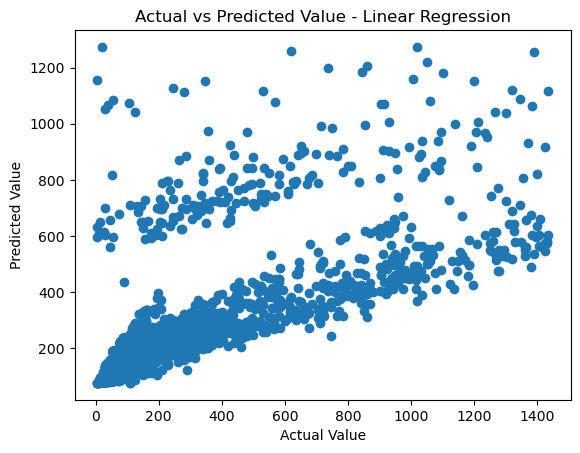

In [81]:
plt.scatter(y_test, test_pred_lr)
plt.title('Actual vs Predicted Value - Linear Regression')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

# ****Level 5: Model Comparison and User Testing****

## ****Task 5.1: Train a basic model using only one input feature****

### ****Since Total Duration have higest correlation with Total Distance. Therefore, let's consider the feature****

In [82]:
X_One = df.drop(['Number_Of_Stops', 'Total_Duration_Minute'], axis=1)
X_One

,Total_Distance
0,78
1,83
2,978
3,2694
4,1618
...,...
11108,34
11109,31
11110,34
11111,34


In [83]:
y_One = df['Total_Duration_Minute']
y_One

0         105.0
1         115.0
2        1325.0
3         480.0
4         750.0
          ...  
11108      50.0
11109      43.0
11110      50.0
11111      52.0
11112      50.0
Name: Total_Duration_Minute, Length: 11058, dtype: float64

In [84]:
X_One_Train, X_One_Test, y_One_Train, y_One_Test = train_test_split(X_One, y_One, test_size=0.2, random_state=42)

In [85]:
X_One_Train

,Total_Distance
6746,139
4114,39
8050,25
8837,123
7328,377
...,...
5783,13
5240,31
5439,57
863,1025


In [86]:
X_One_Test

,Total_Distance
9596,10
7587,535
10656,28
3041,157
5551,37
...,...
7295,92
2419,1663
5166,82
10718,10


In [87]:
y_One_Train

6746     305.0
4114      64.0
8050      45.0
8837     205.0
7328     550.0
         ...  
5783      35.0
5240      70.0
5439     135.0
863     1110.0
7321     275.0
Name: Total_Duration_Minute, Length: 8846, dtype: float64

In [88]:
y_One_Test

9596      15.0
7587     895.0
10656     47.0
3041     260.0
5551      83.0
         ...  
7295     165.0
2419     550.0
5166     135.0
10718     20.0
481      520.0
Name: Total_Duration_Minute, Length: 2212, dtype: float64

### ****We are going to use tree based algorithms since the dataset is non-linear and in the form of tabulated structure.****

### ****We are splitting dataset again since Tree Based Models don't need Standardization****

In [89]:
X = df.drop('Total_Duration_Minute', axis=1)
X

,Total_Distance,Number_Of_Stops
0,78,4
1,83,4
2,978,22
3,2694,14
4,1618,12
...,...,...
11108,34,12
11109,31,11
11110,34,12
11111,34,12


In [90]:
y = df['Total_Duration_Minute']
y

0         105.0
1         115.0
2        1325.0
3         480.0
4         750.0
          ...  
11108      50.0
11109      43.0
11110      50.0
11111      52.0
11112      50.0
Name: Total_Duration_Minute, Length: 11058, dtype: float64

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
X_train

,Total_Distance,Number_Of_Stops
6746,139,19
4114,39,17
8050,25,7
8837,123,20
7328,377,37
...,...,...
5783,13,2
5240,31,14
5439,57,14
863,1025,14


In [93]:
X_test

,Total_Distance,Number_Of_Stops
9596,10,2
7587,535,59
10656,28,2
3041,157,6
5551,37,22
...,...,...
7295,92,11
2419,1663,39
5166,82,21
10718,10,2


In [94]:
y_train

6746     305.0
4114      64.0
8050      45.0
8837     205.0
7328     550.0
         ...  
5783      35.0
5240      70.0
5439     135.0
863     1110.0
7321     275.0
Name: Total_Duration_Minute, Length: 8846, dtype: float64

In [95]:
y_test

9596      15.0
7587     895.0
10656     47.0
3041     260.0
5551      83.0
         ...  
7295     165.0
2419     550.0
5166     135.0
10718     20.0
481      520.0
Name: Total_Duration_Minute, Length: 2212, dtype: float64

### ****We can tune the model to give better results by giving best hyperparamaters to the model found using GridSearchCV or RandomizedSearchCV. We are using GridSearchCV since it gives better results than RandomizedSearchCV even though it takes lot of computing.****

In [96]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

parameter_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,     
    verbose=2
)

grid_search_rf.fit(X_One_Train, y_One_Train)

grid_search_rf.best_params_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 500}

In [97]:
model_rf1 = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
model_rf1.fit(X_One_Train, y_One_Train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamp

In [98]:
train_pred_rf1 = model_rf1.predict(X_One_Train)
test_pred_rf1 = model_rf1.predict(X_One_Test)

In [99]:
train_mae_rf1 = mean_absolute_error(y_One_Train, train_pred_rf1)
test_mae_rf1 = mean_absolute_error(y_One_Test, test_pred_rf1)

In [100]:
train_rmse_rf1 = root_mean_squared_error(y_One_Train, train_pred_rf1)
test_rmse_rf1 = root_mean_squared_error(y_One_Test, test_pred_rf1)

In [101]:
train_r2_rf1 = r2_score(y_One_Train, train_pred_rf1)
test_r2_rf1 = r2_score(y_One_Test, test_pred_rf1)

In [102]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

parameter_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb = XGBRegressor(random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_One_Train, y_train)

grid_search_xgb.best_params_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

In [103]:
model_xgb1 = XGBRegressor(**grid_search_xgb.best_params_, random_state=42)
model_xgb1.fit(X_One_Train, y_One_Train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [104]:
train_pred_xgb1 = model_xgb1.predict(X_One_Train)
test_pred_xgb1 = model_xgb1.predict(X_One_Test)

In [105]:
train_mae_xgb1 = mean_absolute_error(y_One_Train, train_pred_xgb1)
test_mae_xgb1 = mean_absolute_error(y_One_Test, test_pred_xgb1)

In [106]:
train_rmse_xgb1 = root_mean_squared_error(y_One_Train, train_pred_xgb1)
test_rmse_xgb1 = root_mean_squared_error(y_One_Test, test_pred_xgb1)

In [107]:
train_r2_xgb1 = r2_score(y_One_Train, train_pred_xgb1)
test_r2_xgb1 = r2_score(y_One_Test, test_pred_xgb1)

In [108]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

parameter_grid= {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 10],
    "min_child_samples": [10, 20, 50],
}

grid_search_lgb = GridSearchCV(
    estimator=lgbm,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_lgb.fit(X_One_Train, y_One_Train)

grid_search_lgb.best_params_

Fitting 3 folds for each of 243 candidates, totalling 729 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 1
[LightGBM] [Info] Start training from score 274.138142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

{'learning_rate': 0.05,
 'max_depth': 6,
 'min_child_samples': 20,
 'n_estimators': 100,
 'num_leaves': 31}

In [109]:
model_lgbm1 = LGBMRegressor(**grid_search_lgb.best_params_, random_state=42)
model_lgbm1.fit(X_One_Train, y_One_Train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 1
[LightGBM] [Info] Start training from score 274.138142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [110]:
train_pred_lgbm1 = model_lgbm1.predict(X_One_Train)
test_pred_lgbm1 = model_lgbm1.predict(X_One_Test)

In [111]:
train_mae_lgbm1 = mean_absolute_error(y_One_Train, train_pred_lgbm1)
test_mae_lgbm1 = mean_absolute_error(y_One_Test, test_pred_lgbm1)

In [112]:
train_rmse_lgbm1 = root_mean_squared_error(y_One_Train, train_pred_lgbm1)
test_rmse_lgbm1 = root_mean_squared_error(y_One_Test, test_pred_lgbm1)

In [113]:
train_r2_lgbm1 = r2_score(y_One_Train, train_pred_lgbm1)
test_r2_lgbm1 = r2_score(y_One_Test, test_pred_lgbm1)

In [114]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(allow_writing_files=False, random_state=42)

parameter_grid = {
    "iterations": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 10],
    "min_data_in_leaf": [10, 20, 50],
    "l2_leaf_reg": [1, 3, 5, 10],
}

grid_search_cat = GridSearchCV(
    estimator=cat,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_cat.fit(X_One_Train, y_One_Train)

grid_search_cat.best_params_

Fitting 3 folds for each of 324 candidates, totalling 972 fits
0:	learn: 307.5631985	total: 144ms	remaining: 1m 12s
1:	learn: 297.3711708	total: 147ms	remaining: 36.5s
2:	learn: 287.4667168	total: 148ms	remaining: 24.6s
3:	learn: 278.5050247	total: 150ms	remaining: 18.6s
4:	learn: 269.4563598	total: 152ms	remaining: 15.1s
5:	learn: 261.1606859	total: 154ms	remaining: 12.7s
6:	learn: 253.3967802	total: 156ms	remaining: 11s
7:	learn: 246.4389328	total: 158ms	remaining: 9.72s
8:	learn: 239.8967681	total: 160ms	remaining: 8.73s
9:	learn: 233.5337974	total: 162ms	remaining: 7.93s
10:	learn: 227.9043816	total: 164ms	remaining: 7.31s
11:	learn: 222.2933744	total: 166ms	remaining: 6.76s
12:	learn: 216.9224443	total: 168ms	remaining: 6.3s
13:	learn: 212.1039259	total: 170ms	remaining: 5.91s
14:	learn: 207.5620332	total: 172ms	remaining: 5.56s
15:	learn: 203.5280379	total: 174ms	remaining: 5.27s
16:	learn: 199.5593270	total: 176ms	remaining: 5s
17:	learn: 196.0694857	total: 178ms	remaining: 4.77

{'depth': 6,
 'iterations': 500,
 'l2_leaf_reg': 10,
 'learning_rate': 0.05,
 'min_data_in_leaf': 10}

In [115]:
model_cat1 = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42)
model_cat1.fit(X_One_Train, y_One_Train)

0:	learn: 307.5631985	total: 1.95ms	remaining: 972ms
1:	learn: 297.3711708	total: 4.31ms	remaining: 1.07s
2:	learn: 287.4667168	total: 6.18ms	remaining: 1.02s
3:	learn: 278.5050247	total: 8.04ms	remaining: 997ms
4:	learn: 269.4563598	total: 10.6ms	remaining: 1.05s
5:	learn: 261.1606859	total: 12.9ms	remaining: 1.06s
6:	learn: 253.3967802	total: 15.4ms	remaining: 1.08s
7:	learn: 246.4389328	total: 17.9ms	remaining: 1.1s
8:	learn: 239.8967681	total: 20.1ms	remaining: 1.1s
9:	learn: 233.5337974	total: 22.4ms	remaining: 1.1s
10:	learn: 227.9043816	total: 25ms	remaining: 1.11s
11:	learn: 222.2933744	total: 27.2ms	remaining: 1.11s
12:	learn: 216.9224443	total: 29.7ms	remaining: 1.11s
13:	learn: 212.1039259	total: 32.3ms	remaining: 1.12s
14:	learn: 207.5620332	total: 34.6ms	remaining: 1.12s
15:	learn: 203.5280379	total: 36.8ms	remaining: 1.11s
16:	learn: 199.5593270	total: 38.9ms	remaining: 1.1s
17:	learn: 196.0694857	total: 40.9ms	remaining: 1.09s
18:	learn: 192.8103845	total: 43ms	remaining

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=10, learning_rate=0.05, loss_function='RMSE', min_data_in_leaf=10, random_state=42)

In [116]:
train_pred_cat1 = model_cat1.predict(X_One_Train)
test_pred_cat1 = model_cat1.predict(X_One_Test)

In [117]:
train_mae_cat1 = mean_absolute_error(y_One_Train, train_pred_cat1)
test_mae_cat1 = mean_absolute_error(y_One_Test, test_pred_cat1)

In [118]:
train_rmse_cat1 = root_mean_squared_error(y_One_Train, train_pred_cat1)
test_rmse_cat1 = root_mean_squared_error(y_One_Test, test_pred_cat1)

In [119]:
train_r2_cat1 = r2_score(y_One_Train, train_pred_cat1)
test_r2_cat1 = r2_score(y_One_Test, test_pred_cat1)

## ****Task 5.2: Train an improved model using multiple input features****

In [120]:
from sklearn.model_selection import GridSearchCV


parameter_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,     
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

grid_search_rf.best_params_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


{'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [121]:
model_rf2 = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
model_rf2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [122]:
train_pred_rf2 = model_rf2.predict(X_train)
test_pred_rf2 = model_rf2.predict(X_test)

In [123]:
train_mae_rf2 = mean_absolute_error(y_train, train_pred_rf2)
test_mae_rf2 = mean_absolute_error(y_test, test_pred_rf2)

In [124]:
train_rmse_rf2 = root_mean_squared_error(y_train, train_pred_rf2)
test_rmse_rf2 = root_mean_squared_error(y_test, test_pred_rf2)

In [125]:
train_r2_rf2 = r2_score(y_train, train_pred_rf2)
test_r2_rf2 = r2_score(y_test, test_pred_rf2)

In [126]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb = XGBRegressor(random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb, 
    param_grid=parameter_grid, 
    cv=3, 
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)

grid_search_xgb.best_params_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 500}

In [127]:
model_xgb2 = XGBRegressor(**grid_search_xgb.best_params_, random_state=42)
model_xgb2.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [128]:
train_pred_xgb2 = model_xgb2.predict(X_train)
test_pred_xgb2 = model_xgb2.predict(X_test)

In [129]:
train_mae_xgb2 = mean_absolute_error(y_train, train_pred_xgb2)
test_mae_xgb2 = mean_absolute_error(y_test, test_pred_xgb2)

In [130]:
train_rmse_xgb2 = root_mean_squared_error(y_train, train_pred_xgb2)
test_rmse_xgb2 = root_mean_squared_error(y_test, test_pred_xgb2)

In [131]:
train_r2_xgb2 = r2_score(y_train, train_pred_xgb2)
test_r2_xgb2 = r2_score(y_test, test_pred_xgb2)

In [132]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

parameter_grid= {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 10],
    "min_child_samples": [10, 20, 50],
}

grid_search_lgb = GridSearchCV(
    estimator=lgbm,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_lgb.fit(X_train, y_train)

grid_search_lgb.best_params_

Fitting 3 folds for each of 243 candidates, totalling 729 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 2
[LightGBM] [Info] Start training from score 274.138142


{'learning_rate': 0.05,
 'max_depth': -1,
 'min_child_samples': 10,
 'n_estimators': 100,
 'num_leaves': 31}

In [133]:
model_lgbm2 = LGBMRegressor(**grid_search_lgb.best_params_, random_state=42)
model_lgbm2.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 2
[LightGBM] [Info] Start training from score 274.138142


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,10


In [134]:
train_pred_lgbm2 = model_lgbm2.predict(X_train)
test_pred_lgbm2 = model_lgbm2.predict(X_test)

In [135]:
train_mae_lgbm2 = mean_absolute_error(y_train, train_pred_lgbm2)
test_mae_lgbm2 = mean_absolute_error(y_test, test_pred_lgbm2)

In [136]:
train_rmse_lgbm2 = root_mean_squared_error(y_train, train_pred_lgbm2)
test_rmse_lgbm2 = root_mean_squared_error(y_test, test_pred_lgbm2)

In [137]:
train_r2_lgbm2 = r2_score(y_train, train_pred_lgbm2)
test_r2_lgbm2 = r2_score(y_test, test_pred_lgbm2)

In [138]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(allow_writing_files=False, random_state=42)

parameter_grid = {
    "iterations": [100, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 10],
    "min_data_in_leaf": [10, 20, 50],
    "l2_leaf_reg": [1, 3, 5, 10],
}

grid_search_cat = GridSearchCV(
    estimator=cat,
    param_grid=parameter_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search_cat.fit(X_train, y_train)

grid_search_cat.best_params_

Fitting 3 folds for each of 324 candidates, totalling 972 fits
0:	learn: 296.1622788	total: 27.4ms	remaining: 2.72s
1:	learn: 275.8059932	total: 55ms	remaining: 2.7s
2:	learn: 258.5123436	total: 81.4ms	remaining: 2.63s
3:	learn: 242.0683014	total: 109ms	remaining: 2.62s
4:	learn: 227.8086125	total: 133ms	remaining: 2.53s
5:	learn: 214.4636664	total: 161ms	remaining: 2.52s
6:	learn: 203.3107335	total: 189ms	remaining: 2.51s
7:	learn: 192.9728447	total: 216ms	remaining: 2.49s
8:	learn: 184.3781356	total: 243ms	remaining: 2.46s
9:	learn: 176.0185007	total: 269ms	remaining: 2.42s
10:	learn: 168.8089713	total: 296ms	remaining: 2.4s
11:	learn: 162.7642898	total: 321ms	remaining: 2.35s
12:	learn: 157.1379592	total: 347ms	remaining: 2.33s
13:	learn: 152.3281003	total: 375ms	remaining: 2.3s
14:	learn: 147.6255215	total: 400ms	remaining: 2.27s
15:	learn: 143.7374746	total: 425ms	remaining: 2.23s
16:	learn: 140.9857157	total: 452ms	remaining: 2.21s
17:	learn: 137.9050734	total: 479ms	remaining: 2

{'depth': 10,
 'iterations': 100,
 'l2_leaf_reg': 1,
 'learning_rate': 0.1,
 'min_data_in_leaf': 10}

In [139]:
model_cat2 = CatBoostRegressor(**grid_search_cat.best_params_, random_state=42)
model_cat2.fit(X_train, y_train)

0:	learn: 296.1622788	total: 28.8ms	remaining: 2.85s
1:	learn: 275.8059932	total: 55.1ms	remaining: 2.7s
2:	learn: 258.5123436	total: 79.3ms	remaining: 2.56s
3:	learn: 242.0683014	total: 104ms	remaining: 2.51s
4:	learn: 227.8086125	total: 130ms	remaining: 2.48s
5:	learn: 214.4636664	total: 159ms	remaining: 2.48s
6:	learn: 203.3107335	total: 187ms	remaining: 2.49s
7:	learn: 192.9728447	total: 216ms	remaining: 2.48s
8:	learn: 184.3781356	total: 244ms	remaining: 2.47s
9:	learn: 176.0185007	total: 270ms	remaining: 2.43s
10:	learn: 168.8089713	total: 297ms	remaining: 2.4s
11:	learn: 162.7642898	total: 326ms	remaining: 2.39s
12:	learn: 157.1379592	total: 352ms	remaining: 2.36s
13:	learn: 152.3281003	total: 380ms	remaining: 2.33s
14:	learn: 147.6255215	total: 407ms	remaining: 2.31s
15:	learn: 143.7374746	total: 434ms	remaining: 2.28s
16:	learn: 140.9857157	total: 462ms	remaining: 2.25s
17:	learn: 137.9050734	total: 486ms	remaining: 2.21s
18:	learn: 135.7928923	total: 515ms	remaining: 2.19s
19

CatBoostRegressor(depth=10, iterations=100, l2_leaf_reg=1, learning_rate=0.1, loss_function='RMSE', min_data_in_leaf=10, random_state=42)

In [140]:
train_pred_cat2 = model_cat2.predict(X_train)
test_pred_cat2 = model_cat2.predict(X_test)

In [141]:
train_mae_cat2 = mean_absolute_error(y_train, train_pred_cat2)
test_mae_cat2 = mean_absolute_error(y_test, test_pred_cat2)

In [142]:
train_rmse_cat2 = root_mean_squared_error(y_train, train_pred_cat2)
test_rmse_cat2 = root_mean_squared_error(y_test, test_pred_cat2)

In [143]:
train_r2_cat2 = r2_score(y_train, train_pred_cat2)
test_r2_cat2 = r2_score(y_test, test_pred_cat2)

In [ ]:
from sklearn.ensemble import VotingRegressor

In [174]:
model_vr = VotingRegressor(
    estimators=[
        ('xgb', model_xgb2),
        ('lgbm', model_lgbm2),
        ('cat', model_cat2),
        ('rf', model_rf2)
    ],
    weights=[0.5, 0.5, 3, 3] 
)
model_vr.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 8846, number of used features: 2
[LightGBM] [Info] Start training from score 274.138142
0:	learn: 296.1622788	total: 24.6ms	remaining: 2.43s
1:	learn: 275.8059932	total: 49ms	remaining: 2.4s
2:	learn: 258.5123436	total: 76.4ms	remaining: 2.47s
3:	learn: 242.0683014	total: 104ms	remaining: 2.48s
4:	learn: 227.8086125	total: 131ms	remaining: 2.49s
5:	learn: 214.4636664	total: 158ms	remaining: 2.47s
6:	learn: 203.3107335	total: 188ms	remaining: 2.5s
7:	learn: 192.9728447	total: 218ms	remaining: 2.51s
8:	learn: 184.3781356	total: 244ms	remaining: 2.47s
9:	learn: 176.0185007	total: 275ms	remaining: 2.47s
10:	learn: 168.8089713	total: 307ms	remaining: 2.48s
11:	learn: 162.7642898	total: 336ms	remaining: 2.46s
12:	learn: 157.1379592	total: 365m

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgb', ...), ('lgbm', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[0.5, 0.5, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None


In [175]:
train_pred_vr = model_vr.predict(X_train)
test_pred_vr = model_vr.predict(X_test)

In [176]:
train_mae_vr = mean_absolute_error(y_train, train_pred_vr)
test_mae_vr = mean_absolute_error(y_test, test_pred_vr)

In [177]:
train_rmse_vr = root_mean_squared_error(y_train, train_pred_vr)
test_rmse_vr = root_mean_squared_error(y_test, test_pred_vr)

In [178]:
train_r2_vr = r2_score(y_train, train_pred_vr)
test_r2_vr = r2_score(y_test, test_pred_vr)

## ****Task 5.3: Compare models using error metrics and visual plots****


In [179]:
train_mae_rf1, test_mae_rf1, train_rmse_rf1, test_rmse_rf1, train_r2_rf1, test_r2_rf1

(55.84145691948763,
 67.3044290161959,
 120.75814855385147,
 157.33021414979643,
 0.856669056347233,
 0.7640971935691213)

In [180]:
train_mae_rf2, test_mae_rf2, train_rmse_rf2, test_rmse_rf2, train_r2_rf2, test_r2_rf2

(32.82499159809725,
 46.60223478349842,
 79.71684208905127,
 131.3045462219304,
 0.9375392433745117,
 0.8356883464459355)

In [181]:
train_mae_xgb1, test_mae_xgb1, train_rmse_xgb1, test_rmse_xgb1, train_r2_xgb1, test_r2_xgb1

(67.73140854051742,
 70.64360653944516,
 147.19932178434885,
 156.5551944022051,
 0.7870298746786236,
 0.7664156168850296)

In [182]:
train_mae_xgb2, test_mae_xgb2, train_rmse_xgb2, test_rmse_xgb2, train_r2_xgb2, test_r2_xgb2

(40.82279177486102,
 50.73783948322317,
 98.18336057679139,
 135.08781624739692,
 0.9052492068377078,
 0.8260833336268617)

In [183]:
train_mae_lgbm1, test_mae_lgbm1, train_rmse_lgbm1, test_rmse_lgbm1, train_r2_lgbm1, test_r2_lgbm1

(66.42012211738341,
 69.85553335472706,
 144.6861065070651,
 154.92972136382463,
 0.7942401055965498,
 0.7712409314464674)

In [184]:
train_mae_lgbm2, test_mae_lgbm2, train_rmse_lgbm2, test_rmse_lgbm2, train_r2_lgbm2, test_r2_lgbm2

(43.76966850594368,
 51.83908083951708,
 97.94374407676973,
 132.08355519926766,
 0.9057111211360263,
 0.8337328931206699)

In [185]:
train_mae_cat1, test_mae_cat1, train_rmse_cat1, test_rmse_cat1, train_r2_cat1, test_r2_cat1

(67.07549074421935,
 69.84414945701845,
 145.65838188551686,
 155.6251269951005,
 0.7914654445148843,
 0.7691827419528892)

In [186]:
train_mae_cat2, test_mae_cat2, train_rmse_cat2, test_rmse_cat2, train_r2_cat2, test_r2_cat2

(45.91033642901189,
 52.33435776562133,
 100.65205133209456,
 129.49450731875913,
 0.9004245381837167,
 0.8401872093629229)

In [187]:
train_mae_vr, test_mae_vr, train_rmse_vr, test_rmse_vr, train_r2_vr, test_r2_vr

(38.90945188174798,
 48.50218836495506,
 89.19303283911404,
 128.59810255343749,
 0.921806809935519,
 0.8423921076791363)

Text(0, 0.5, 'Predicted Value')

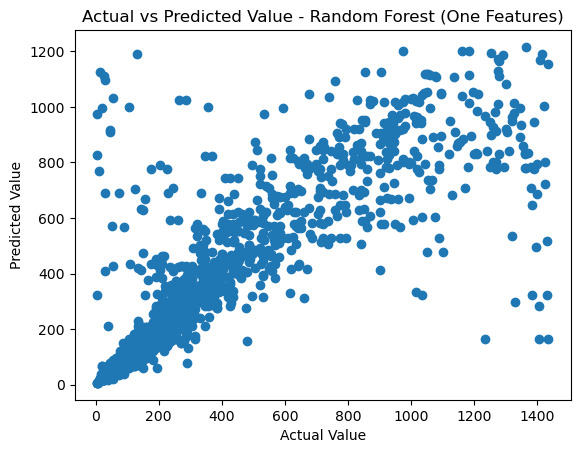

In [152]:
plt.scatter(y_test, test_pred_rf1)
plt.title('Actual vs Predicted Value - Random Forest (One Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

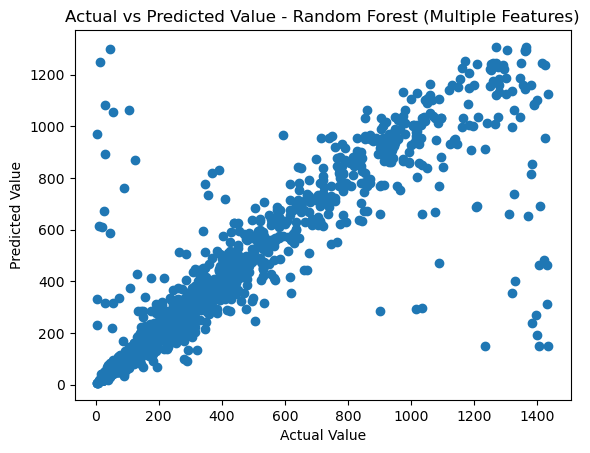

In [153]:
plt.scatter(y_test, test_pred_rf2)
plt.title('Actual vs Predicted Value - Random Forest (Multiple Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

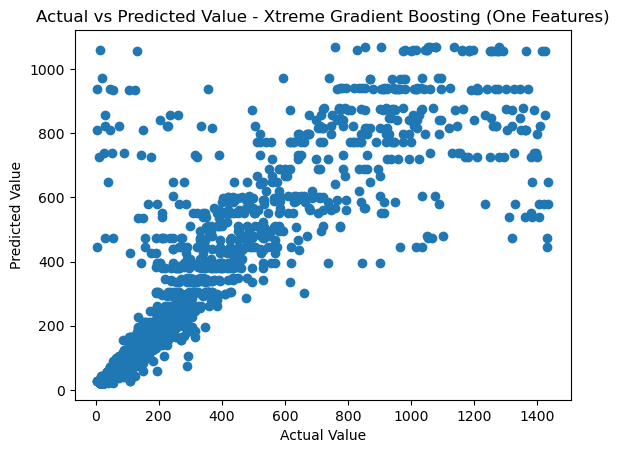

In [154]:
plt.scatter(y_test, test_pred_xgb1)
plt.title('Actual vs Predicted Value - Xtreme Gradient Boosting (One Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

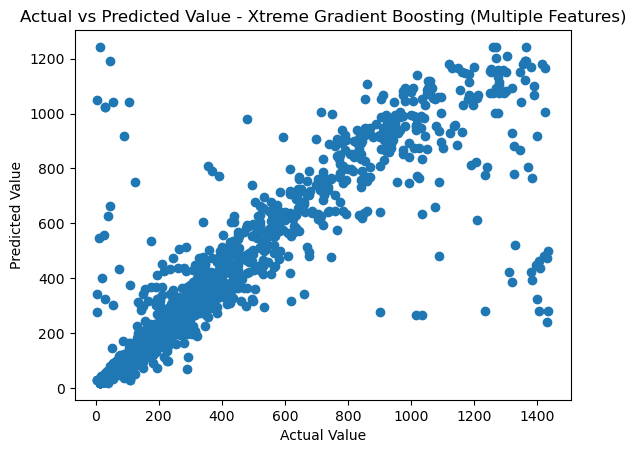

In [155]:
plt.scatter(y_test, test_pred_xgb2)
plt.title('Actual vs Predicted Value - Xtreme Gradient Boosting (Multiple Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

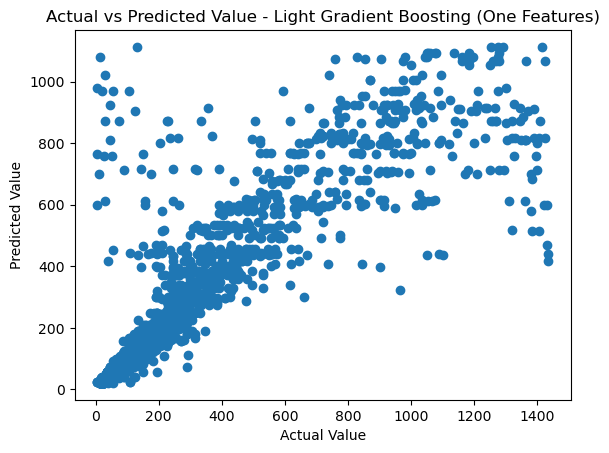

In [156]:
plt.scatter(y_test, test_pred_lgbm1)
plt.title('Actual vs Predicted Value - Light Gradient Boosting (One Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

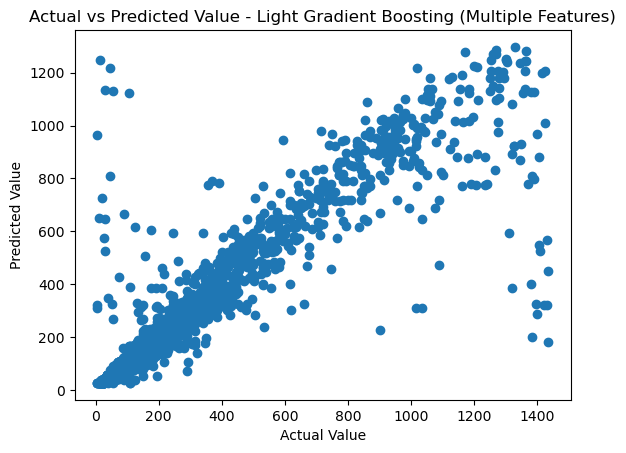

In [157]:
plt.scatter(y_test, test_pred_lgbm2)
plt.title('Actual vs Predicted Value - Light Gradient Boosting (Multiple Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

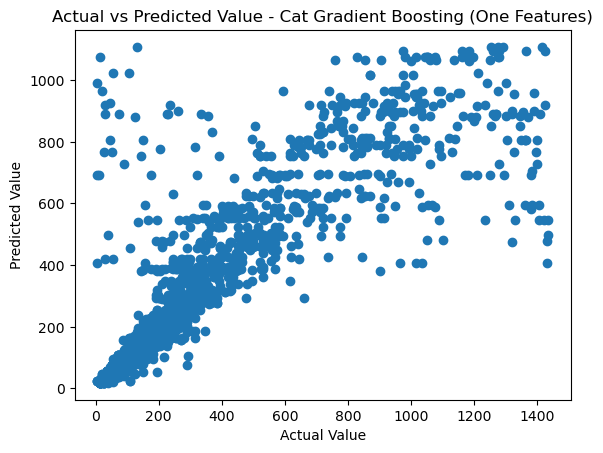

In [158]:
plt.scatter(y_test, test_pred_cat1)
plt.title('Actual vs Predicted Value - Cat Gradient Boosting (One Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

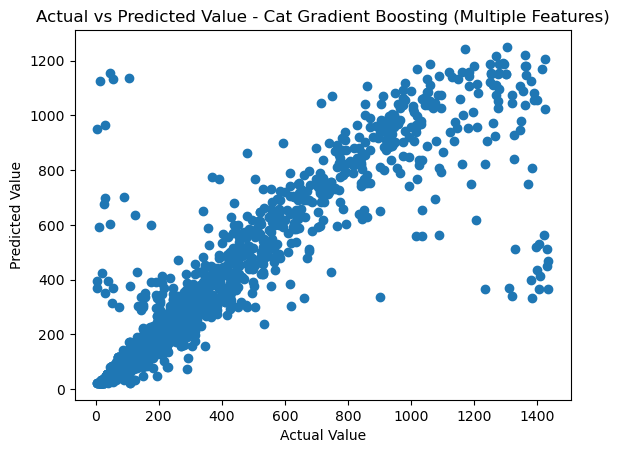

In [159]:
plt.scatter(y_test, test_pred_cat2)
plt.title('Actual vs Predicted Value - Cat Gradient Boosting (Multiple Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

Text(0, 0.5, 'Predicted Value')

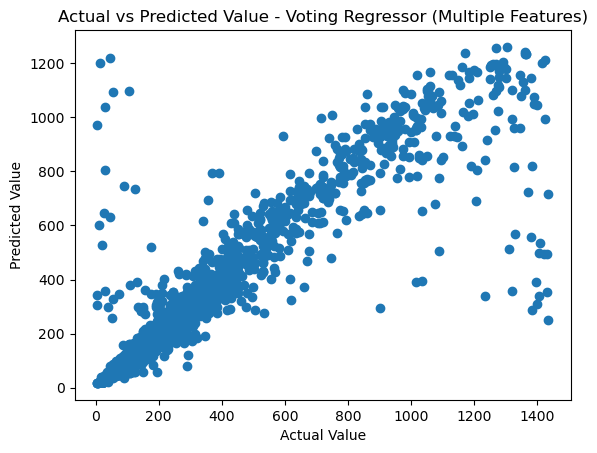

In [173]:
plt.scatter(y_test, test_pred_vr)
plt.title('Actual vs Predicted Value - Voting Regressor (Multiple Features)')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')

## ****Task 5.4: Select the model with better performance based on evaluation****

### ****We have chosen Random Forest (Multiple Features) since it gives better MAE and RMSE. Even though the model overfits and gives less rsquare score than Categorical Boosting, it works well in test dataset.****

In [ ]:
import joblib

In [ ]:
joblib.dump(model_vr, 'Machine Learning Model.pkl')

['Machine Learning Model.pkl']